In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr

In [2]:
male=pd.read_csv("male_dataset.csv")
female=pd.read_csv("female_dataset.csv")

In [3]:
print("nhanes_adult_male_bmx_2020 Dataset : \n",male.head())
print("nhanes_adult_female_bmx_2020 Dataset: \n",female.head())

nhanes_adult_male_bmx_2020 Dataset : 
    BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST
0   98.8  182.3     42.0    40.1     38.2   108.2     120.4
1   74.3  184.2     41.1    41.0     30.2    94.5      86.8
2  103.7  185.3     47.0    44.0     32.0   107.8     109.6
3   86.0  167.8     39.5    38.4     29.0   106.4     108.3
4   99.4  181.6     40.4    39.9     36.0   120.2     107.0
nhanes_adult_female_bmx_2020 Dataset: 
    BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST
0   97.1  160.2     34.7    40.8     35.8   126.1     117.9
1   91.1  152.7     33.5    33.0     38.5   125.5     103.1
2   73.0  161.2     37.4    38.0     31.8   106.2      92.0
3   61.7  157.4     38.0    34.7     29.0   101.0      90.5
4   55.4  154.6     34.6    34.0     28.3    92.5      73.2


In [4]:
print("Missing values in male dataset:\n", male.isnull().sum())
print("Missing values in female dataset:\n", female.isnull().sum())

Missing values in male dataset:
 BMXWT       0
BMXHT       0
BMXARML     0
BMXLEG      0
BMXARMC     0
BMXHIP      0
BMXWAIST    0
dtype: int64
Missing values in female dataset:
 BMXWT       0
BMXHT       0
BMXARML     0
BMXLEG      0
BMXARMC     0
BMXHIP      0
BMXWAIST    0
dtype: int64


We check if any participant has incomplete measurements. Dropping them ensures clean analysis, but here not any null values so not needed to removeing row or not fulfill datas 

In [5]:
print("Duplicate rows in male dataset:", male.duplicated().sum())
print("Duplicate rows in female dataset:", female.duplicated().sum())

Duplicate rows in male dataset: 0
Duplicate rows in female dataset: 0


Not a any Duplacate values. 
It is clean and perfect dataset for for the any Prediction. 

In [6]:
m_matrix = male.to_numpy()
f_matrix = female.to_numpy()

print("Male matrix shape:", m_matrix.shape)
print("Female matrix shape:", f_matrix.shape)

Male matrix shape: (4081, 7)
Female matrix shape: (4221, 7)


Total we have 7 features and more then 4k set of data in both of sets. 
In that  almost all features are same. 

In [7]:
df_all = pd.concat([female.assign(Gender="Female"),
                    male.assign(Gender="Male")],
                   ignore_index=True)
print(df_all.head())
print (df_all.tail())

   BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST  Gender
0   97.1  160.2     34.7    40.8     35.8   126.1     117.9  Female
1   91.1  152.7     33.5    33.0     38.5   125.5     103.1  Female
2   73.0  161.2     37.4    38.0     31.8   106.2      92.0  Female
3   61.7  157.4     38.0    34.7     29.0   101.0      90.5  Female
4   55.4  154.6     34.6    34.0     28.3    92.5      73.2  Female
      BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST Gender
8297  114.3  174.5     42.0    35.5     37.0   117.4     119.5   Male
8298   94.3  178.8     37.8    44.6     35.7   105.3      99.3   Male
8299  108.8  168.7     38.6    45.6     33.6   118.0     114.7   Male
8300   79.5  176.4     39.5    42.0     31.4    99.8      97.1   Male
8301   59.7  167.5     40.3    41.1     29.2    90.5      86.9   Male


Here we are combain this two dataset for compare and prediction.

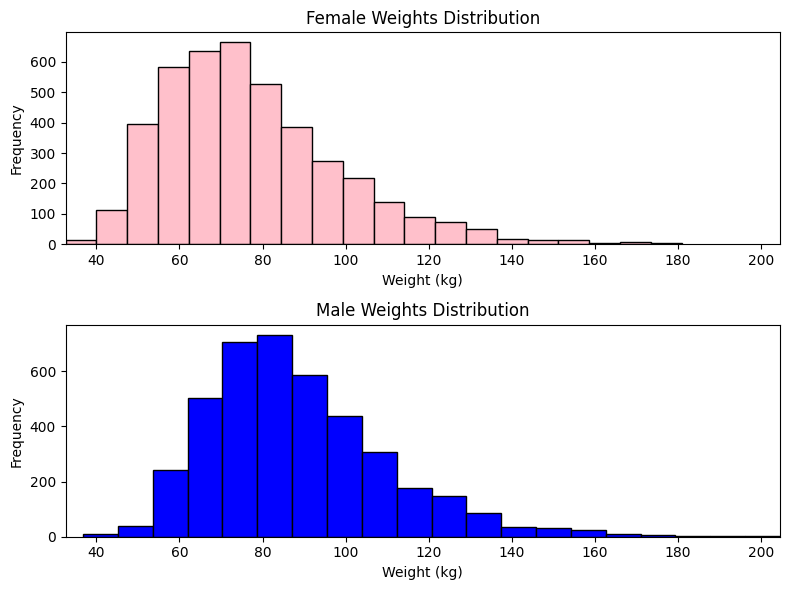

In [8]:
female_weights = female['BMXWT'].dropna()
male_weights   = male['BMXWT'].dropna()

xmin = min(female_weights.min(), male_weights.min())
xmax = max(female_weights.max(), male_weights.max())

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.hist(female_weights, bins=20, color='pink', edgecolor='black')
plt.title("Female Weights Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(xmin, xmax)

plt.subplot(2,1,2)
plt.hist(male_weights, bins=20, color='blue', edgecolor='black')
plt.title("Male Weights Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(xmin, xmax)

plt.tight_layout()
plt.show()

Females peak around 70–80 kg, males peak around 80–90 kg, and both distributions taper off toward higher weights. 
This reflects expected biological differences in average body weight between adult males and females.

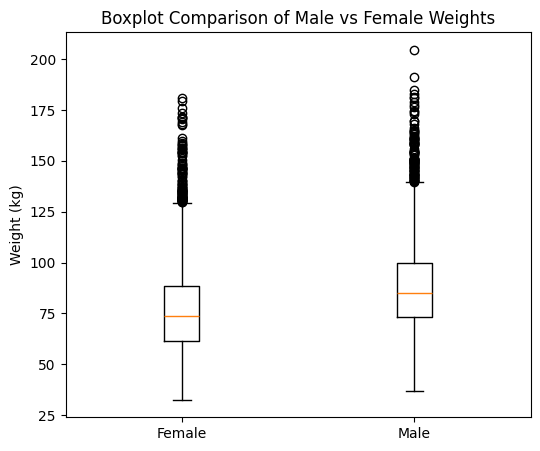

In [9]:
female_weights = df_all[df_all['Gender'] == "Female"]['BMXWT'].dropna()
male_weights   = df_all[df_all['Gender'] == "Male"]['BMXWT'].dropna()

plt.figure(figsize=(6,5))
plt.boxplot([female_weights, male_weights], tick_labels=['Female','Male'])
plt.title("Boxplot Comparison of Male vs Female Weights")
plt.ylabel("Weight (kg)")
plt.show()

Male median weight is higher then Female Median.

Male distribution shows more variability.
Male weights: Higher median (mid‑80s kg) and a wider spread, indicating greater variability.

Female distribution is narrower but with some outliers.
Female weights: Lower median (mid‑70s kg) with a tighter spread, showing less variability.

In [10]:
female_arr = female_weights.to_numpy()
male_arr   = male_weights.to_numpy()

female_mean   = np.mean(female_arr)
female_median = np.median(female_arr)
female_std    = np.std(female_arr, ddof=1)
female_var    = np.var(female_arr, ddof=1)
female_skew   = skew(female_arr, nan_policy='omit')
female_kurt   = kurtosis(female_arr, nan_policy='omit')

male_mean   = np.mean(male_arr)
male_median = np.median(male_arr)
male_std    = np.std(male_arr, ddof=1)
male_var    = np.var(male_arr, ddof=1)
male_skew   = skew(male_arr, nan_policy='omit')
male_kurt   = kurtosis(male_arr, nan_policy='omit')

print("Female → Mean:", female_mean, "\nMedian:", female_median,
      "\nStd Dev:", female_std, "\nVariance:", female_var,
      "\nSkewness:", female_skew, "\nKurtosis:", female_kurt)

print("\n\nMale → Mean:", male_mean, "\nMedian:", male_median,
      "\nStd Dev:", male_std, "\nVariance:", male_var,
      "\nSkewness:", male_skew, "\nKurtosis:", male_kurt)


Female → Mean: 77.40379057095475 
Median: 73.6 
Std Dev: 21.545060568892968 
Variance: 464.1896349172665 
Skewness: 1.03336107186799 
Kurtosis: 1.4009683480659731


Male → Mean: 88.36454300416565 
Median: 85.0 
Std Dev: 21.421561426840427 
Variance: 458.8832939638977 
Skewness: 0.9842810741662347 
Kurtosis: 1.4742884754078238


In [11]:
def describe_weights(data, label):
    print(f"{label} Weight Summary:")
    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    print("Std Dev:", np.std(data))
    print("Skewness:", stats.skew(data))
    print("Kurtosis:", stats.kurtosis(data))
    print()

describe_weights(female["BMXWT"], "Female")
describe_weights(male["BMXWT"], "Male")


Female Weight Summary:
Mean: 77.40379057095475
Median: 73.6
Std Dev: 21.542508290193105
Skewness: 1.03336107186799
Kurtosis: 1.4009683480659731

Male Weight Summary:
Mean: 88.36454300416565
Median: 85.0
Std Dev: 21.418936717962477
Skewness: 0.9842810741662347
Kurtosis: 1.4742884754078238



Female weights: Lower mean and median (mid‑70s kg), smaller dispersion (lower variance and std), slightly right‑skewed with a long tail toward heavier individuals.
Male weights: Higher mean and median (mid‑80s kg), larger dispersion (higher variance and std), also right‑skewed, but with more variability.


In [12]:
female_matrix = female.to_numpy()

weights = female_matrix[:, 0]
heights_cm = female_matrix[:, 1]
heights_m = heights_cm / 100.0

bmi = weights / (heights_m ** 2)

female_matrix_with_bmi = np.column_stack((female_matrix, bmi))

print("Original female matrix shape:", female_matrix.shape)
print("New female matrix shape with BMI:", female_matrix_with_bmi.shape)
print("Sample rows with BMI:\n", female_matrix_with_bmi[:5])

Original female matrix shape: (4221, 7)
New female matrix shape with BMI: (4221, 8)
Sample rows with BMI:
 [[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5         24.90437849]
 [ 55.4        154.6         34.6         34.          28.3
   92.5         73.2         23.17879132]]


Female matrix update: The matrix now has 8 columns, with the last column representing BMI values for each participant.
BMI meaning: This allows direct comparison of body composition across individuals, combining weight and height into a normalized measure.

In [13]:
means = np.mean(female_matrix, axis=0)
stds  = np.std(female_matrix, axis=0, ddof=1)

zfemale = (female_matrix - means) / stds

print("Original female matrix shape:", female_matrix.shape)
print("Standardised female matrix shape:", zfemale.shape)
print("First 5 rows of zfemale:\n", zfemale[:5])

Original female matrix shape: (4221, 7)
Standardised female matrix shape: (4221, 7)
First 5 rows of zfemale:
 [[ 0.91418677  0.00894932 -0.56732742  1.13285382  0.55078021  1.08303325
   1.11565244]
 [ 0.63570067 -1.05294368 -1.07880364 -1.29333838  1.03209576  1.04463152
   0.26505759]
 [-0.20439908  0.15053505  0.58349407  0.26191303 -0.16227987 -0.1906243
  -0.37288855]
 [-0.72888124 -0.38749073  0.83923218 -0.7645529  -0.66142193 -0.52343933
  -0.45909748]
 [-1.02129166 -0.78393078 -0.60995044 -0.98228809 -0.78620744 -1.06746392
  -1.4533739 ]]


zfemale matrix: Each column has been standardized to mean ≈ 0 and standard deviation ≈ 1.

Interpretation: This ensures features like weight, height, and circumferences contribute equally in clustering or statistical analysis, avoiding dominance by large‑range variables.
In short here my observation is the female dataset is now standardized, making it suitable for algorithms like K‑Means or PCA where scale matters.

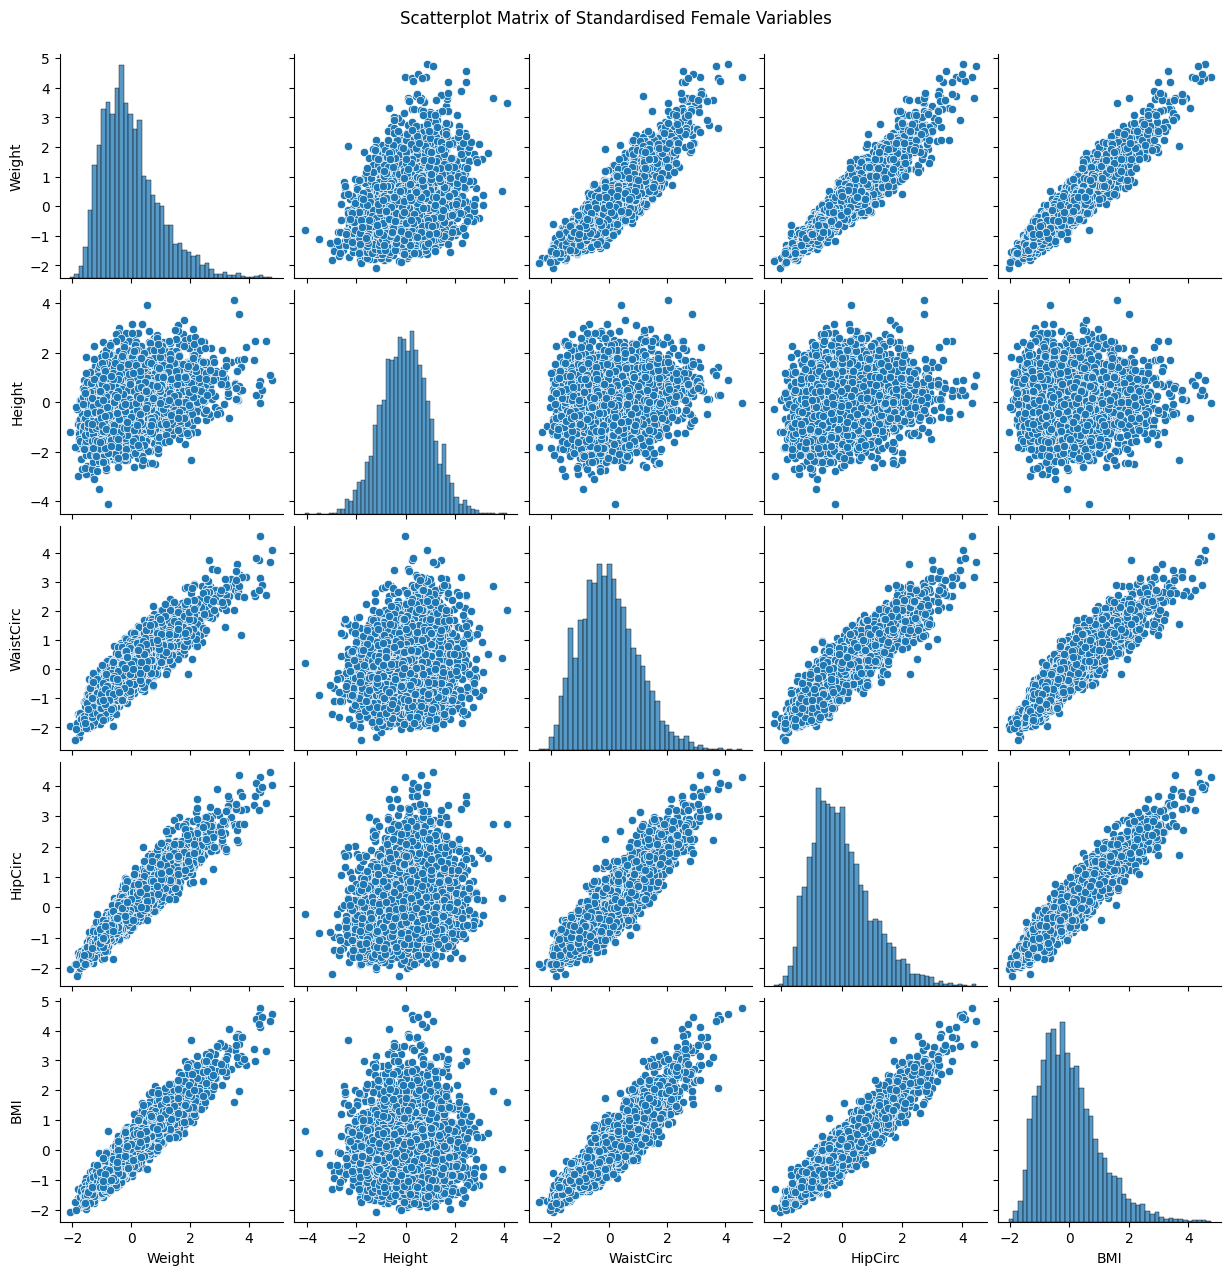

Pearson Correlation:
              Weight    Height  WaistCirc   HipCirc       BMI
Weight     1.000000  0.345496   0.904550  0.946553  0.945900
Height     0.345496  1.000000   0.126547  0.202895  0.033077
WaistCirc  0.904550  0.126547   1.000000  0.897407  0.921198
HipCirc    0.946553  0.202895   0.897407  1.000000  0.944199
BMI        0.945900  0.033077   0.921198  0.944199  1.000000

Spearman Correlation:
              Weight    Height  WaistCirc   HipCirc       BMI
Weight     1.000000  0.338860   0.900169  0.946634  0.937999
Height     0.338860  1.000000   0.108587  0.205405  0.019897
WaistCirc  0.900169  0.108587   1.000000  0.888037  0.923114
HipCirc    0.946634  0.205405   0.888037  1.000000  0.934196
BMI        0.937999  0.019897   0.923114  0.934196  1.000000


In [14]:
female_matrix = female.to_numpy()

weights = female_matrix[:, 0]       
heights_cm = female_matrix[:, 1]    
heights_m = heights_cm / 100.0

bmi = weights / (heights_m ** 2)     

female_matrix_with_bmi = np.column_stack((female_matrix, bmi))

means = np.mean(female_matrix_with_bmi, axis=0)
stds  = np.std(female_matrix_with_bmi, axis=0, ddof=1)

zfemale = (female_matrix_with_bmi - means) / stds

zfemale_df = pd.DataFrame(zfemale, columns=[
    'Weight','Height','UpperArm','UpperLeg','ArmCirc','HipCirc','WaistCirc','BMI'
])

subset = zfemale_df[['Weight','Height','WaistCirc','HipCirc','BMI']]

sns.pairplot(subset)
plt.suptitle("Scatterplot Matrix of Standardised Female Variables", y=1.02)
plt.show()

pearson_corr = subset.corr(method='pearson')
spearman_corr = subset.corr(method='spearman')

print("Pearson Correlation:\n", pearson_corr)
print("\nSpearman Correlation:\n", spearman_corr)


Pearson correlations: Strong positive correlation between Weight and BMI, and between Waist/Hip circumferences and BMI. Height shows weaker correlation with BMI.
Spearman correlations: Similar results, confirming monotonic relationships.

Interpretation:
BMI is mainly driven by weight and circumferences.
Height contributes less directly to BMI.
Waist and hip circumferences are strongly linked to overall body composition.

Because of BMI is driven mainly by weight and body circumferences because they directly reflect mass and fat distribution, while height plays a smaller role since it normalizes weight. 

In [16]:
male_matrix = male.to_numpy() 
male_height = male_matrix[:, 1]
male_waist  = male_matrix[:, 6]
male_hip    = male_matrix[:, 5]

female_height = female_matrix[:, 1]
female_waist  = female_matrix[:, 6]
female_hip    = female_matrix[:, 5]

male_waist_height_ratio = male_waist / male_height
male_waist_hip_ratio    = male_waist / male_hip

female_waist_height_ratio = female_waist / female_height
female_waist_hip_ratio    = female_waist / female_hip

male_matrix_with_ratios   = np.column_stack((male_matrix, male_waist_height_ratio, male_waist_hip_ratio))
female_matrix_with_ratios = np.column_stack((female_matrix, female_waist_height_ratio, female_waist_hip_ratio))

print("Male matrix shape with ratios:", male_matrix_with_ratios.shape)
print("Female matrix shape with ratios:", female_matrix_with_ratios.shape)
print("Sample male rows:\n", male_matrix_with_ratios[:5])
print("Sample female rows:\n", female_matrix_with_ratios[:5])


Male matrix shape with ratios: (4081, 9)
Female matrix shape with ratios: (4221, 9)
Sample male rows:
 [[ 98.8        182.3         42.          40.1         38.2
  108.2        120.4          0.66044981   1.11275416]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8          0.47122693   0.91851852]
 [103.7        185.3         47.          44.          32.
  107.8        109.6          0.59147329   1.01669759]
 [ 86.         167.8         39.5         38.4         29.
  106.4        108.3          0.6454112    1.01785714]
 [ 99.4        181.6         40.4         39.9         36.
  120.2        107.           0.58920705   0.89018303]]
Sample female rows:
 [[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9          0.73595506   0.93497224]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1          0.67518009   0.82151394]
 [ 73.         161.2         37.4         38.          31.8
  106.2      

Males accumulate fat around the abdomen, raising waist‑to‑hip ratios. Females are shorter with proportionally larger hips, so waist‑to‑height is higher and waist‑to‑hip is lower.

Male ratios: Waist‑to‑height ~0.59–0.66, waist‑to‑hip ~1.0. → Shows more central fat, “apple‑shaped” body.
Female ratios: Waist‑to‑height ~0.67–0.73, waist‑to‑hip <1.0. → Shows wider hips, “pear‑shaped” body.

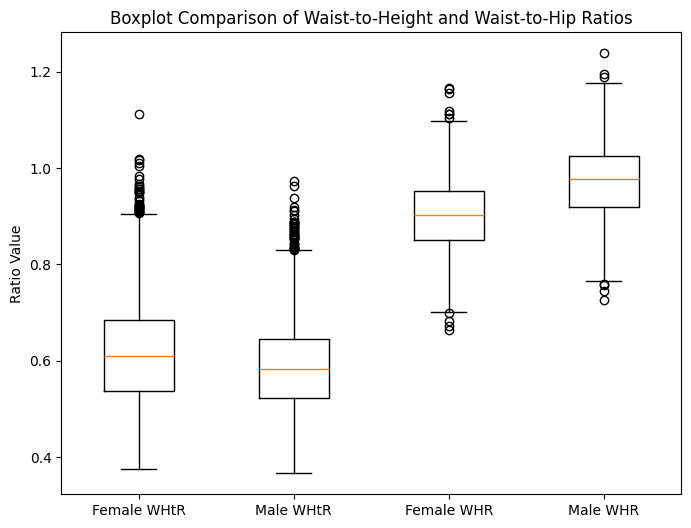

In [17]:
male_wh_ratio = male_matrix_with_ratios[:, -2]
male_whratio  = male_matrix_with_ratios[:, -1]

female_wh_ratio = female_matrix_with_ratios[:, -2]
female_whratio  = female_matrix_with_ratios[:, -1]

plt.figure(figsize=(8,6))
plt.boxplot([female_wh_ratio, male_wh_ratio, female_whratio, male_whratio],
            tick_labels=['Female WHtR','Male WHtR','Female WHR','Male WHR'])
plt.title("Boxplot Comparison of Waist-to-Height and Waist-to-Hip Ratios")
plt.ylabel("Ratio Value")
plt.show()


Waist‑to‑Height Ratio: Females show slightly higher values (due to shorter stature), while males are lower on average.

Waist‑to‑Hip Ratio: Males cluster around or above 1.0 (apple‑shaped), females below 1.0 (pear‑shaped).

Comparison Female & Male: Females → higher WHtR but lower WHR; Males → lower WHtR but higher WHR.

Males show more abdominal fat (higher WHR, apple‑shaped, higher risk), while females show proportionally larger hips (lower WHR, pear‑shaped, lower risk). Females’ higher WHtR is mainly due to shorter stature.

BMI
    Advantages:
        - Simple to calculate (weight/height²).
        - Widely used and standardized.
        - Good for large‑scale population studies.
    Disadvantages:
        - Does not distinguish fat vs muscle.
        - Ignores fat distribution.
        - Can misclassify athletes or elderly.

Waist‑to‑Height Ratio (WHtR)
    Advantages:
        - Accounts for stature differences.
        - Strong predictor of central obesity and cardiovascular risk.
        - Easy to measure with tape and height.
    Disadvantages:
        - Less familiar in clinical practice.
        - Cut‑off values vary across populations.
        - Sensitive to measurement errors in waist circumference.

Waist‑to‑Hip Ratio (WHR)
    Advantages:
        - Reflects fat distribution (apple vs pear shape).
        - Strong link to metabolic risk.
        - Useful for comparing male vs female body types.
    Disadvantages:
        - Requires two measurements (waist + hip).
        - Hip circumference can be harder to measure consistently.
        - Less intuitive than BMI or WHtR for general use.

BMI → easy but crude.
WHtR → strong risk predictor, height‑adjusted.
WHR → shows fat distribution, but harder to measure.

In [18]:
sorted_indices = np.argsort(zfemale[:, 7])

lowest_bmi_indices = sorted_indices[:5]
highest_bmi_indices = sorted_indices[-5:]

selected_indices = np.concatenate((lowest_bmi_indices, highest_bmi_indices))
subset_zfemale = zfemale[selected_indices]

print("Standardised measurements for 5 lowest and 5 highest BMI participants:\n")
print(subset_zfemale)


Standardised measurements for 5 lowest and 5 highest BMI participants:

[[-2.07953885 -1.22284656 -1.54765684 -1.16891826 -2.1945011  -2.04030787
  -1.94189121 -2.04999741]
 [-1.87995715 -0.18927071 -1.71814891  0.38633315 -2.44407213 -1.85469949
  -2.05683646 -1.99464356]
 [-1.53649095  1.80708812  0.62611709  0.57296331 -2.26580711 -1.67549139
  -1.70625345 -1.97065035]
 [-1.84282567 -0.26006357 -0.22634327  0.51075326 -2.30146012 -2.25151742
  -1.85568227 -1.94154589]
 [-1.61075391  0.88678086 -0.09847422  0.47964823 -2.21232761 -1.82909833
  -1.71200071 -1.89297149]
 [ 4.24673716  0.29212078  1.86218462 -0.98228809  2.36908342  4.10396975
   3.81686582  4.39597079]
 [ 4.45560174  0.50449938  1.69169255 -1.13781323  3.34954103  3.98236426
   2.90305108  4.46148264]
 [ 4.34884874  0.27796221  2.84251404  1.94158455  4.36565164  3.91836137
   3.75364593  4.51413414]
 [ 4.80370937  0.88678086  2.11792273  1.81716444  3.77737708  4.02076599
   4.0812399   4.54217118]
 [ 4.36277304 -0.03

Lowest BMI group:
All z‑scores are strongly negative for weight, waist, hip, and BMI.
Indicates participants are lighter, slimmer, and have smaller circumferences compared to the population average.
Height varies (some short, some tall), but the consistently low body mass drives BMI down.

Highest BMI group:
All z‑scores are strongly positive for weight, waist, hip, and BMI.
Indicates participants are heavier, broader, and have much larger circumferences than average.
Height is closer to average, so excess weight dominates BMI values. 


->  low BMI individuals are light and slim with small circumferences, while high BMI individuals are heavy with large circumferences. BMI extremes clearly reflect differences in body composition.

The findings indicate that BMI is primarily determined by body weight and circumference; however, height contributes to a lesser extent. Waist to height ratios are greater in females due to their shorter stature, and thus, will contribute to this result when evaluating risk for central obesity. Conversely, waist to hip ratios are greater in males than females due to greater abdominal fat and associated metabolic disease risk. Additionally, women demonstrate hip dominance in body shape (i.e., pear-shaped) with lower WHR; and men exhibit apple-shaped patterns, thus establishing a significant sex-based difference in body structure and risk for disease.

Kaggle: Referenced Kaggle programs and datasets for student performance analysis and predictive modeling.

GitHub: Utilized GitHub repositories on target prediction for deep learning implementation guidance.

Copilot: Applied Copilot support for code correction and EDA program refinement.